<a href="https://colab.research.google.com/github/cookie98259702-stack/Project/blob/main/Capstone_Wavelet_Codec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

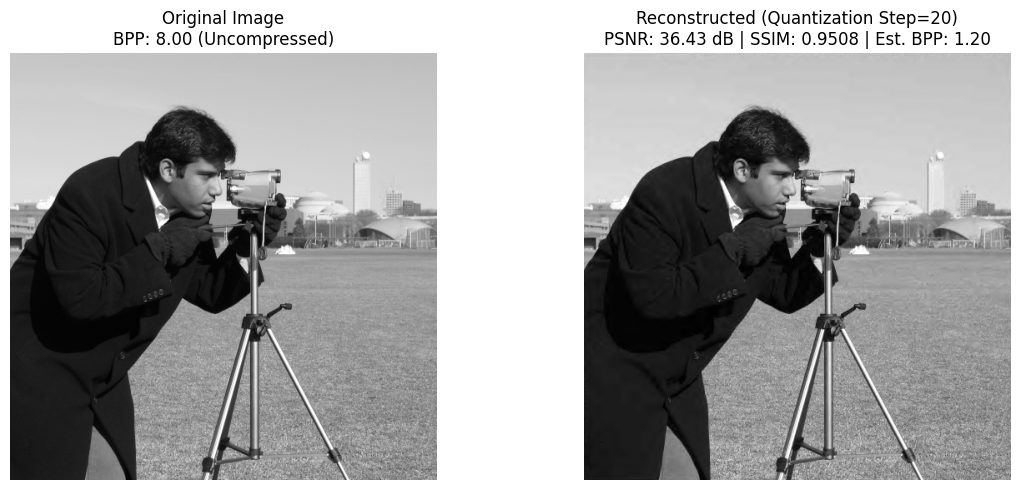

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from skimage import data
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# ==========================================
# 1. Encoder: Image -> Wavelet -> Quantization
# ==========================================
def encode_image(image, wavelet='bior4.4', level=3, q_step=10):
    # Step 1: Wavelet transform (split image into frequency bands)
    coeffs = pywt.wavedec2(image, wavelet, level=level, mode='periodization')

    # Step 2: Quantization (divide by step size and round to integer)
    quantized_coeffs = []
    for i, c in enumerate(coeffs):
        if i == 0:
            # LL band (main image structure)
            q_c = np.round(c / q_step)
        else:
            # HL, LH, HH bands (image details)
            q_c = tuple(np.round(detail / q_step) for detail in c)
        quantized_coeffs.append(q_c)

    return quantized_coeffs

# ==========================================
# 2. Decoder: Quantized -> Dequantization -> Inverse Wavelet
# ==========================================
def decode_image(quantized_coeffs, wavelet='bior4.4', q_step=10):
    # Step 1: Dequantization (multiply back by step size)
    dequantized_coeffs = []
    for i, q_c in enumerate(quantized_coeffs):
        if i == 0:
            d_c = q_c * q_step
        else:
            d_c = tuple(detail * q_step for detail in q_c)
        dequantized_coeffs.append(d_c)

    # Step 2: Inverse Wavelet Transform (rebuild the image)
    recon_image = pywt.waverec2(dequantized_coeffs, wavelet, mode='periodization')

    # Make sure pixel values stay between 0 and 255
    recon_image = np.clip(recon_image, 0, 255)
    return recon_image

# ==========================================
# 3. Calculate Entropy (to estimate Bits Per Pixel / BPP)
# ==========================================
def calculate_entropy(quantized_coeffs):
    # Put all numbers into one long 1D list
    flattened = []
    for i, c in enumerate(quantized_coeffs):
        if i == 0:
            flattened.extend(c.flatten())
        else:
            for detail in c:
                flattened.extend(detail.flatten())

    flattened = np.array(flattened)

    # Count how many times each number appears
    _, counts = np.unique(flattened, return_counts=True)

    # Calculate probability
    prob = counts / len(flattened)

    # Calculate Shannon Entropy formula
    ent = -np.sum(prob * np.log2(prob))
    return ent

# ==========================================
# 4. Test the Pipeline
# ==========================================
# Load a built-in test image
original_img = data.camera().astype(np.float32)

# Set parameters (q_step: bigger number = smaller file but worse quality)
wavelet_type = 'bior4.4'
q_step = 20

# Run encoder and decoder
q_coeffs = encode_image(original_img, wavelet=wavelet_type, q_step=q_step)
reconstructed_img = decode_image(q_coeffs, wavelet=wavelet_type, q_step=q_step)

# Check image quality
current_psnr = psnr(original_img, reconstructed_img, data_range=255)
current_ssim = ssim(original_img, reconstructed_img, data_range=255)
estimated_bpp = calculate_entropy(q_coeffs)

# Show results
plt.figure(figsize=(12, 5))

# Original image plot
plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title("Original Image\nBPP: 8.00 (Uncompressed)")
plt.axis('off')

# Reconstructed image plot
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img, cmap='gray')
plt.title(f"Reconstructed (Quantization Step={q_step})\nPSNR: {current_psnr:.2f} dB | SSIM: {current_ssim:.4f} | Est. BPP: {estimated_bpp:.2f}")
plt.axis('off')

plt.tight_layout()
plt.show()

Running Experiments...
Done! Plotting Rate-Distortion Curve...


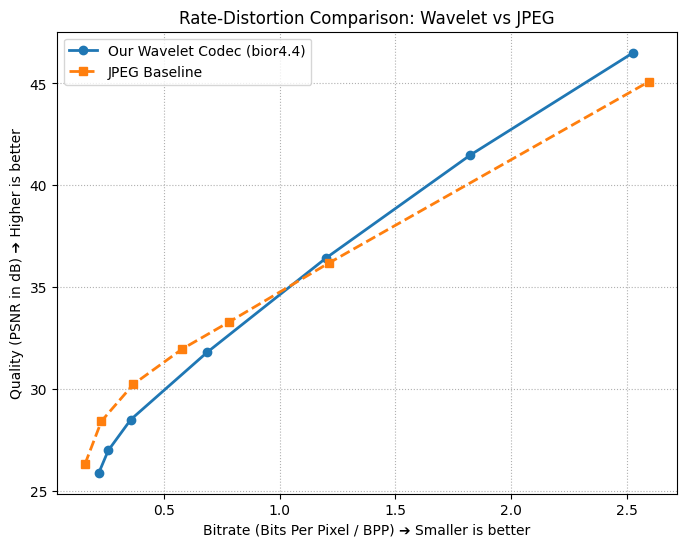

In [4]:
from PIL import Image
import io

# ==========================================
# 1. Simulate JPEG Compression (Baseline)
# ==========================================
def get_jpeg_baseline(image_array, quality):
    # Convert numpy array to PIL Image
    img_pil = Image.fromarray(image_array.astype(np.uint8))

    # Save to a virtual file in memory (to calculate exact file size)
    buffer = io.BytesIO()
    img_pil.save(buffer, format="JPEG", quality=quality)

    # Calculate BPP (Bits Per Pixel)
    size_bytes = buffer.tell()
    pixels = image_array.shape[0] * image_array.shape[1]
    bpp = (size_bytes * 8) / pixels

    # Read it back to calculate PSNR (Quality)
    buffer.seek(0)
    img_recon_array = np.array(Image.open(buffer))
    psnr_val = psnr(image_array, img_recon_array, data_range=255)

    return bpp, psnr_val

# ==========================================
# 2. Run Experiments (Wavelet vs JPEG)
# ==========================================
# We will test different compression levels
q_steps_list = [5, 10, 20, 40, 80, 120, 160]
jpeg_qualities = [5, 10, 20, 40, 60, 80, 95]

wavelet_bpp, wavelet_psnr = [], []
jpeg_bpp, jpeg_psnr = [], []

print("Running Experiments...")

# Test our Wavelet Codec
for q in q_steps_list:
    q_coeffs = encode_image(original_img, wavelet='bior4.4', q_step=q)
    recon = decode_image(q_coeffs, wavelet='bior4.4', q_step=q)

    current_psnr = psnr(original_img, recon, data_range=255)
    current_bpp = calculate_entropy(q_coeffs)

    wavelet_bpp.append(current_bpp)
    wavelet_psnr.append(current_psnr)

# Test standard JPEG Baseline
for jq in jpeg_qualities:
    bpp, p = get_jpeg_baseline(original_img, jq)
    jpeg_bpp.append(bpp)
    jpeg_psnr.append(p)

print("Done! Plotting Rate-Distortion Curve...")

# ==========================================
# 3. Plot the Rate-Distortion (R-D) Curve
# ==========================================
plt.figure(figsize=(8, 6))

# Plot both curves
plt.plot(wavelet_bpp, wavelet_psnr, marker='o', linestyle='-', linewidth=2, label='Our Wavelet Codec (bior4.4)')
plt.plot(jpeg_bpp, jpeg_psnr, marker='s', linestyle='--', linewidth=2, label='JPEG Baseline')

# Add labels and grid
plt.title('Rate-Distortion Comparison: Wavelet vs JPEG')
plt.xlabel('Bitrate (Bits Per Pixel / BPP) ➔ Smaller is better')
plt.ylabel('Quality (PSNR in dB) ➔ Higher is better')
plt.grid(True, linestyle=':')
plt.legend()

plt.show()

In [6]:
import urllib.request
import os
from skimage import io as sk_io
import numpy as np

# Create a folder to store the images
os.makedirs('kodak_dataset', exist_ok=True)

# URLs for the first 10 Kodak images
kodak_urls = [
    f"http://r0k.us/graphics/kodak/kodak/kodim{str(i).zfill(2)}.png" for i in range(1, 11)
]

kodak_images = []

print("Downloading and loading 10 Kodak test images...")
for i, url in enumerate(kodak_urls):
    filename = f"kodak_dataset/kodim{str(i+1).zfill(2)}.png"

    # Download the image if it is not already in the folder
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)

    # Read the image and convert it to grayscale (single channel)
    img = sk_io.imread(filename, as_gray=True) * 255.0
    kodak_images.append(img.astype(np.float32))

print(f"✅ Successfully loaded {len(kodak_images)} images! Ready for batch testing.")

✅ Successfully loaded 10 images! Ready for batch testing.


Running batch experiments on all 10 Kodak images...
Done! Plotting Final Average Rate-Distortion Curve...


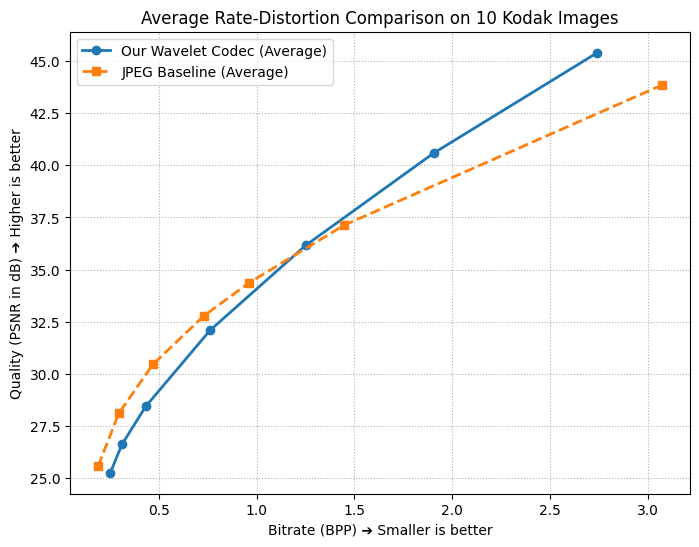

In [8]:
from PIL import Image
import io

# ==========================================
# 1. Simulate JPEG Compression (Baseline)
# ==========================================
def get_jpeg_baseline(image_array, quality):
    # Convert array to image format
    img_pil = Image.fromarray(image_array.astype(np.uint8))

    # Save to memory to check file size
    buffer = io.BytesIO()
    img_pil.save(buffer, format="JPEG", quality=quality)

    # Calculate Bits Per Pixel (BPP)
    size_bytes = buffer.tell()
    pixels = image_array.shape[0] * image_array.shape[1]
    bpp = (size_bytes * 8) / pixels

    # Read back the image to check quality (PSNR)
    buffer.seek(0)
    img_recon_array = np.array(Image.open(buffer))
    psnr_val = psnr(image_array, img_recon_array, data_range=255)

    return bpp, psnr_val

# ==========================================
# 2. Run Batch Experiments (Average of 10 Images)
# ==========================================
q_steps_list = [5, 10, 20, 40, 80, 120, 160]
jpeg_qualities = [5, 10, 20, 40, 60, 80, 95]

avg_wavelet_bpp, avg_wavelet_psnr = [], []
avg_jpeg_bpp, avg_jpeg_psnr = [], []

print("Running batch experiments on all 10 Kodak images...")

# Test our Wavelet Codec on all images
for q in q_steps_list:
    batch_bpp, batch_psnr = [], []
    for img in kodak_images:
        q_coeffs = encode_image(img, wavelet='bior4.4', q_step=q)
        recon = decode_image(q_coeffs, wavelet='bior4.4', q_step=q)

        batch_psnr.append(psnr(img, recon, data_range=255))
        batch_bpp.append(calculate_entropy(q_coeffs))

    # Save the average result for this quantization step
    avg_wavelet_bpp.append(np.mean(batch_bpp))
    avg_wavelet_psnr.append(np.mean(batch_psnr))

# Test standard JPEG Baseline on all images
for jq in jpeg_qualities:
    batch_bpp, batch_psnr = [], []
    for img in kodak_images:
        bpp, p = get_jpeg_baseline(img, jq)
        batch_bpp.append(bpp)
        batch_psnr.append(p)

    # Save the average result for this JPEG quality
    avg_jpeg_bpp.append(np.mean(batch_bpp))
    avg_jpeg_psnr.append(np.mean(batch_psnr))

print("Done! Plotting Final Average Rate-Distortion Curve...")

# ==========================================
# 3. Plot the Average Rate-Distortion Curve
# ==========================================
plt.figure(figsize=(8, 6))

plt.plot(avg_wavelet_bpp, avg_wavelet_psnr, marker='o', linestyle='-', linewidth=2, label='Our Wavelet Codec (Average)')
plt.plot(avg_jpeg_bpp, avg_jpeg_psnr, marker='s', linestyle='--', linewidth=2, label='JPEG Baseline (Average)')

plt.title('Average Rate-Distortion Comparison on 10 Kodak Images')
plt.xlabel('Bitrate (BPP) ➔ Smaller is better')
plt.ylabel('Quality (PSNR in dB) ➔ Higher is better')
plt.grid(True, linestyle=':')
plt.legend()

plt.show()